In [1]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import random

In [2]:
class fish_tank(object):
    def __init__(self, n, tank1, tank2, tank3):
        self.n = n
        self.tank1 = tank1 #list# probabilities in tank1 in B-O-G order
        self.tank2 = tank2 #list# probabilities in tank2 in B-O-G order
        self.tank3 = tank3 #list# probabilities in tank3 in B-O-G order
        self.tanks = [self.tank1,self.tank2,self.tank3]
        self.history = []
        self.t = 0
        

        if sum(self.tank1) != 1:
            raise Warning("probabilities in tank1 does not add up to 1")

        if sum(self.tank2) != 1:
            raise Warning("probabilities in tank2 does not add up to 1")

        if sum(self.tank3) != 1:
            raise Warning("probabilities in tank3 does not add up to 1")

    def step(self, tank):
        self.history.append(np.random.choice([0, 1, 2], 1, p = tank)[0])
        self.t = self.t + 1
        
    def reset(self):
        self.history = []
        self.t = 0

    def choose_block(self):
        bl = [0,1,1,1,1,1,1,1,1,2] #10 blocks with # of reversals (1 0 reversal, 8 1 reversals, 1 2 reversal)
        block1 = np.random.permutation(bl)
        block2 = np.random.permutation(bl)
        block3 = np.random.permutation(bl)
        
        blocks = [block1, block2, block3]
        bl = np.random.choice(3)
        return(blocks[bl])
            
    def visualize(self):
        fig, ax = plt.subplots(1,3, figsize = (15,5))
        ax[0].pie(self.tank1, labels=['Blue', 'Orange', 'Green'])
        ax[0].set_title('Tank 1- Fish distribution', fontsize = 12)
        ax[1].pie(self.tank2, labels=['Blue', 'Orange', 'Green'])
        ax[1].set_title('Tank 2- Fish distribution', fontsize = 12)
        ax[2].pie(self.tank3, labels=['Blue', 'Orange', 'Green'])
        ax[2].set_title('Tank 3- Fish distribution', fontsize = 12)

class agent(object):
    def __init__(self, policy = None, **kwargs):
        self.choices = np.array([0, 1, 2])
        self.policy = policy
        
        if self.policy == 'heuristic':
            self.p = kwargs['p']
        elif self.policy == 'RL':
            self.alpha = kwargs['alpha']
            self.tau = kwargs['tau']
        elif self.policy == 'BL':
            self.lmbda = kwargs['lmbda']
            s = (1-self.lmbda)/2
            self.llhood = np.array(([[0,1,1],
                              [1,0,1],
                              [1,1,0]]))*s + np.eye(3)*self.lmbda #each column is initial probs (m,s/2,s/2), (s/2,m,s/2)  etc ..
        else:
            Warning('Select a Policy')

    def iterateTrials_heuristic(self, TANKS_, tank_no, est_prob, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])#agennt makes a prediction

        #prob update
        est_prob[trial+1,observ] = est_prob[trial,observ] + self.p
        est_prob[trial+1,:] = self.compute_prob(est_prob[trial+1,:], option = 'Normalize') #likelihood * prior/ sum(likelihood*prior)
        return(pred, est_prob)

    def iterateTrials_RL(self, TANKS_, tank_no, est_prob, est_value, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])
        
        if pred == tank_no:
            reward = 100
        else:
            reward = 0
        #value update with Rescorla-Wagner
        est_value = self.update_vals(est_value, trial, pred, reward)#, option = 'unchanged') ##keeping un-updated entries the same OPTIONS: 1)unchanged 2) update with a reward 1 3) complemntary
        est_prob[trial+1,:] = self.compute_prob(est_value[trial+1,:], option = 'Softmax')
        return(pred, est_prob, est_value)

    def iterateTrials_BL(self, TANKS_, tank_no, est_post, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_post[trial-1,:])[0]
                
        if trial == 0:
            prob = est_post[trial,:] #no prior in the first trial so posterior(t) = prior(t)
        else: 
            prob = est_post[trial-1,:] # prior = posterior(t-1)
                    
        #belief update
        den = np.dot(self.llhood[observ,:], prob) #prob of the data under all the hypothesis
        est_post[trial,:] = np.multiply(self.llhood[observ,:], prob)/den #likelihood * prior/ sum(likelihood*prior)
        
        est_post[trial,:] = np.maximum(0.005, est_post[trial,:]) #we don't want posteiror to get too small and no convergence
        est_post[trial,:] = est_post[trial,:]/est_post[trial,:].sum()
        return(pred, est_post) 

    def compute_prob(self, val, option):#options 1)Normalize 2)softmax
        if option == 'Normalize':
            prob = (val)/(val.sum())
        elif option == 'Softmax':
            prob = (np.exp(val/self.tau))/(np.exp(val/self.tau).sum())
        return(prob)

    def update_vals(self, vals, trial, pred, rwrd):#, option = 'unchanged'):
        #if option == 'unchanged':
        vals[trial+1,:] = vals[trial,:]
        vals[trial+1,pred] = vals[trial,pred] + self.alpha*(rwrd-vals[trial,pred])
        return(vals)

    def initialize_prob(self, n_trials, option = 'Softmax'):
        if self.policy == 'heuristic':
            prob = np.ones((n_trials+1, len(self.choices)))/len(self.choices)
            return(prob)
        
        elif self.policy == 'RL':#reinforcemnet learning Rescorla Wagner
            value = np.zeros((n_trials+1, 3)) #3 choices
            prob = np.zeros((n_trials+1, 3)) 
            value[0,:] = [33,33,33] #make an initial random choice
            prob[0,:] = self.compute_prob(value[0,:], option = option)  ##OPTIIONS: 1) normalization 2) softmax
            return(value, prob)
            
        elif self.policy == 'BL': # Bayesian Learning
            prob = np.ones((n_trials, len(self.choices)))/len(self.choices)#3 is number of fish *POSTERIOR*
            return(prob)

def listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds, name, TANKS_, tank_no, block, trial, pred):
    subjects.append('Subject%d'%name)
    blocks.append(block)
    trials.append(trial)
    preds.append(pred[0])
    trues.append((pred == tank_no)[0])
    rewards.append(100*(pred == tank_no)[0])
    sources.append(tank_no)
    observeds.append(TANKS_.history[trial])
    return(subjects, blocks, trials, preds, trues, rewards, sources, observeds)

def gradient_alpha(tau_, val, prev_val, rwrd, pred): 
    #current value (1x3 vector), previous value(1x3 vector), current reward(scalar)
    #derivative of loglikelihood is derivative of log(softmax())
    
    #derivative of logsum
    df_alpha_DEN_NUM = np.dot((rwrd-prev_val)/tau_, np.exp(val/tau_))
    df_alpha_DEN_DEN = (np.exp(val/tau_).sum())
    df_alpha_DEN = df_alpha_DEN_NUM/df_alpha_DEN_DEN
    df_alpha = []
    for _ in range(3):
        df_alpha_NUM = (rwrd-prev_val[_])/tau_
        df_alpha.append(df_alpha_NUM - df_alpha_DEN)
    return(df_alpha[pred])
    
def gradient_tau(tau_, val, prev_val, rwrd, pred): 
    #current value (1x3 vector), previous value(1x3 vector), current reward(scalar) 
    #derivative of loglikelihood is derivative of log(softmax())
    
    #derivative of logsum
    df_tau_DEN_NUM = np.dot((-1*val/tau_**2), np.exp(val/tau_)) 
    df_tau_DEN_DEN = (np.exp(val/tau_).sum())
    df_tau_DEN = df_tau_DEN_NUM/df_tau_DEN_DEN
    
    df_tau = []
    for _ in range(3):
        df_tau_NUM = -1*val[_]/tau_**2
        df_tau.append(df_tau_NUM - df_tau_DEN)
        
    return(df_tau[pred])   

In [3]:
tank1 = [0.8,0.1,0.1] #Probabilities of B-O-G
tank2 = [0.1,0.8,0.1] #Probabilities of B-O-G
tank3 = [0.1,0.1,0.8] #Probabilities of B-O-G

TANKS = fish_tank(3,tank1,tank2,tank3)

## GENERATE data with RW with parameters:

In [5]:
nTrials = 15
nSubject = 8

alphas = np.linspace(0,1,nSubject)
taus = 2**np.linspace(0,5,nSubject)

subjects, blocks, trials, preds, trues, rewards, sources, observeds = [], [], [], [], [], [], [], []

for s in range(nSubject):
    the_block = TANKS.choose_block()
    AGENT = agent(policy = 'RL', tau = taus[s], alpha = alphas[s])
    for b, block in enumerate(the_block):
        est_value, est_prob = AGENT.initialize_prob(nTrials, option = 'Softmax')   
        if block == 0:
            reversal = 0
            the_tank = np.random.choice(3,1, replace = False) # choose ONE tank to draw fish from
            for i in range(nTrials):
                prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[0], est_prob, est_value, i)
                subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                 s, TANKS, the_tank[0], b, i, prediction)
                
        elif block == 1:
            reversal = np.sort(np.random.randint(low = 1, high = int(nTrials-1), size = (1)))[0]
            the_tank = np.random.choice(3,2, replace = False) # choose TWO tanks to draw fish from
            for i in range(nTrials):
                if  i < reversal:
                    prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[0], est_prob, est_value, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                     s, TANKS, the_tank[0], b, i, prediction)      
                else:
                    prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[1], est_prob, est_value, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                     s, TANKS, the_tank[1], b, i, prediction)
        else:
            reversal = np.sort(np.random.randint(low = 1, high = int(nTrials-1), size = (2)))
            the_tank = np.random.choice(3,3, replace = False) # choose THREE tanks to draw fish from
            for i in range(nTrials):
                if  i < reversal[0]:
                    prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[0], est_prob, est_value, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                       s, TANKS, the_tank[0], b, i, prediction,)
                elif reversal[0] <= i < reversal[1]:
                    prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[1], est_prob, est_value, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                     s, TANKS, the_tank[1], b, i, prediction)
                else:
                    prediction, est_prob, est_value  = AGENT.iterateTrials_RL(TANKS, the_tank[2], est_prob, est_value, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                                     s, TANKS, the_tank[2], b, i, prediction)
        TANKS.reset()#reset history of every tank after each block

In [6]:
df = pd.DataFrame({'SubjectID':subjects, 'BlockID':blocks, 'TrialID':trials, 'PredLabels':preds, 'Truth':trues, 'Reward':rewards, 'TrueLabels':sources, 'ObservedLabel':observeds})
df.head()

,SubjectID,BlockID,TrialID,PredLabels,Truth,Reward,TrueLabels,ObservedLabel
0,Subject0,0,0,2,False,0,1,1
1,Subject0,0,1,1,True,100,1,0
2,Subject0,0,2,0,False,0,1,1
3,Subject0,0,3,2,False,0,1,1
4,Subject0,0,4,1,False,0,0,0


## implement grid search for the free parameters: paramater fitting

In [9]:
nBlocks = len(the_block)

alphas = np.linspace(0,1,101)
taus = 2**np.linspace(0,5,21)

iter_errors = np.zeros((nSubject, len(alphas), len(taus)))
best_param = {}

for n in range(nSubject):
    for a, alpha in enumerate(alphas):
        for t, tau in enumerate(taus):
            AGENT = agent(policy = 'RL', alpha = alpha, tau = tau)#initialize the artificial agent. ONLY FOR functionality purposes.
            error = np.zeros((nBlocks, nTrials))
            for b in range(nBlocks):
                est_value, est_prob = AGENT.initialize_prob(nTrials, option = 'Softmax')
                for i in range(nTrials):
                    #get the choices from DF
                    pred = df[(df.SubjectID == 'Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].PredLabels.to_numpy()[0]
                    reward = df[(df.SubjectID =='Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].Reward.to_numpy()[0]
                    #error estimation
                    error[b,i] = np.log(est_prob[i, pred]) ##positive loglikelihood OR LINEAR (1- est_prob[i,pred])
                    #value update with Rescorla-Wagner
                    est_value = AGENT.update_vals(est_value, i, pred, reward)#, option = 'unchanged') ##keeping un-updated entries the same OPTIONS: 1)unchanged 2) update with a reward 1 3) complemntary
                    est_prob[i+1,:] = AGENT.compute_prob(est_value[i+1,:], option = 'Softmax')
            iter_errors[n,a,t] = error.sum()
    a_,t_ = np.unravel_index(np.argmax(iter_errors[n,:,:]), iter_errors[n,:,:].shape)
    best_param['Subject%d'%n] = (alphas[a_], taus[t_])

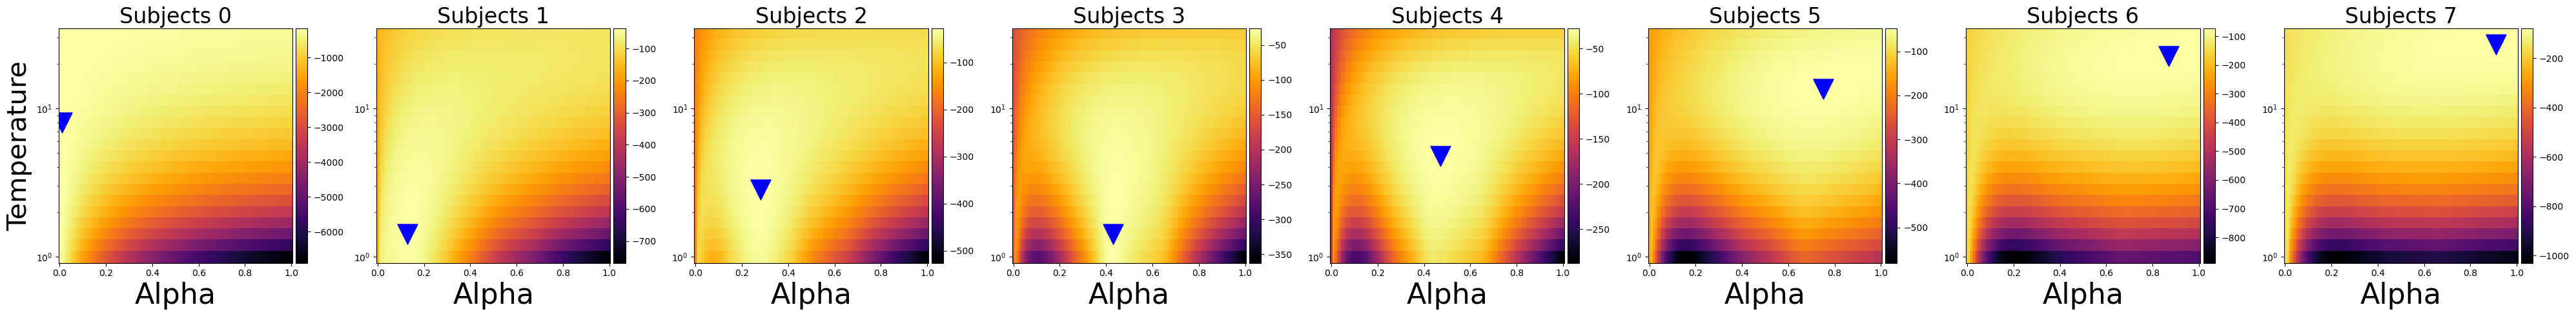

In [10]:
X, Y = np.meshgrid(taus, alphas)

fig,ax = plt.subplots(1, nSubject, figsize = (40,5))
for s in range(nSubject):
    im = ax[s].pcolormesh(Y, X, iter_errors[s,:,:], cmap = 'inferno')
    ax[s].scatter(best_param['Subject%d'%s][0], best_param['Subject%d'%s][1], s = 500, c = 'blue', marker = 'v')

    # ax[s].set_xticks([k*5 for k in range(9)])
    # ax[s].set_yticks([k*0.2 for k in range(6)])        
    ax[s].set_xlabel('Alpha', fontsize = 32)
    ax[s].set_title('Subjects %d'%s, fontsize = 24)
    ax[s].set_yscale('log')
    divider = make_axes_locatable(ax[s])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax)
ax[0].set_ylabel('Temperature', fontsize = 30)

plt.tight_layout()

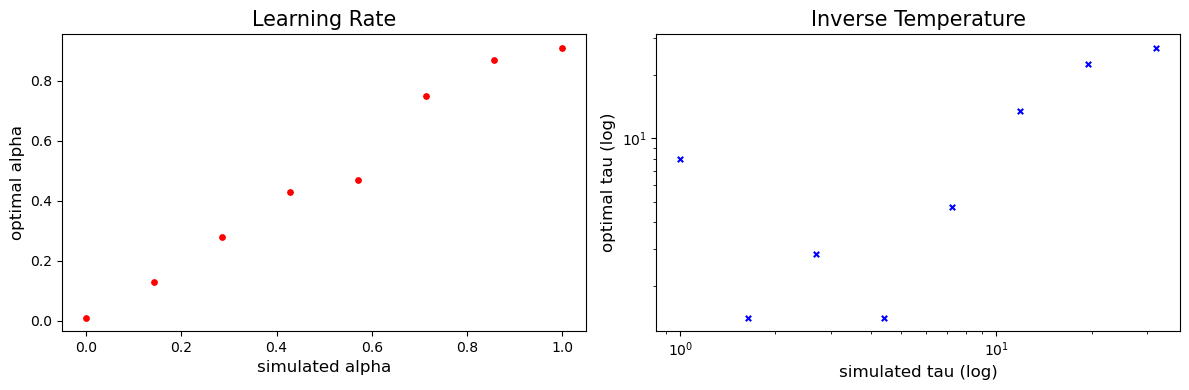

In [11]:
fig, ax = plt.subplots(1,2, figsize = (12,4))
for n in range(nSubject):
    sc0 = ax[0].scatter(np.linspace(0,1,nSubject)[n], best_param['Subject%d'%n][0], s = 15, c = 'red', marker = 'o')
    sc1 = ax[1].scatter(2**np.linspace(0,5,nSubject)[n], best_param['Subject%d'%n][1], s = 15, c = 'blue', marker = 'x')
ax[0].set_xlabel(f'simulated alpha', fontsize = 12)
ax[0].set_ylabel(f'optimal alpha', fontsize = 12)
ax[0].set_title('Learning Rate', fontsize = 15)

ax[1].set_xlabel(f'simulated tau (log)', fontsize = 12)
ax[1].set_ylabel(f'optimal tau (log)', fontsize = 12)
ax[1].set_title('Inverse Temperature', fontsize = 15)
ax[1].set_xscale('log')
ax[1].set_yscale('log')

# x0 = [best_param['Subject%d'%n][0] for n in range(nSubject)]
# y0 = [best_param['Subject%d'%n][0] for n in range(nSubject)]
# m0, b0 = np.polyfit(x0, y0, deg=1)
# l0 = ax[0].axline(xy1=(0, b0), slope=m0, color='black', alpha = 0.5)
# ax[0].legend(handles = [sc0, l0], labels = ['sim_subjects', f'$y = {m0:.2f}x {b0:+.2f}$'])

# x1 = [best_param['Subject%d'%n][1] for n in range(nSubject)]
# y1 = [best_param['Subject%d'%n][1] for n in range(nSubject)]
# m1, b1 = np.polyfit(x1, y1, deg=1)
# l1 = ax[1].axline(xy1=(0, b1), slope=m1, color='black', alpha = 0.5)
# ax[1].legend(handles = [sc1, l1], labels = ['sim_subjects', f'$y = {m1:.2f}x {b1:+.2f}$'])

plt.tight_layout()

In [12]:
best_param

{'Subject0': (0.01, 8.0),
 'Subject1': (0.13, 1.4142135623730951),
 'Subject2': (0.28, 2.8284271247461903),
 'Subject3': (0.43, 1.4142135623730951),
 'Subject4': (0.47000000000000003, 4.756828460010884),
 'Subject5': (0.75, 13.454342644059432),
 'Subject6': (0.87, 22.627416997969522),
 'Subject7': (0.91, 26.908685288118864)}

## implement gradient descent for the free parameters: Parameter fitting

In [15]:
n_iter = 1000
tolerance = 0.00001
nBlocks = len(the_block)
learn_rates = [(0.001,0.1),(0.0001,0.1)]
start = (0.1,3)

iteration_errors = {}
gradient_trajectories = {} 

for s in range(nSubject):
    for l, learn_rate in enumerate(learn_rates):
        iter_error = np.zeros((n_iter))
        grad_traject = np.zeros((n_iter+1, 2))
        grad_traject[0,:] = start
        vector = grad_traject[0,:]
        for _ in range(n_iter):
            error = np.zeros((nBlocks, nTrials))
            AGENT = agent(policy = 'RL', alpha = vector[0], tau = vector[1])
            d_alpha = 0
            d_tau = 0
            for b in range(nBlocks):
                est_value, est_prob = AGENT.initialize_prob(nTrials, option = 'Softmax')
                for i in range(nTrials):  
                    #get the choices from DF
                    pred = df[(df.SubjectID == 'Subject%d'%s)&(df.BlockID == b)&(df.TrialID == i)].PredLabels.to_numpy()[0]
                    reward = df[(df.SubjectID =='Subject%d'%s)&(df.BlockID == b)&(df.TrialID == i)].Reward.to_numpy()[0]
                    
                    #error estimation
                    error[b,i] = abs(np.log(est_prob[i, pred])) ##positive loglikelihood OR LINEAR (1- est_prob[i,pred])
                    
                    #value update with Rescorla-Wagner
                    est_value = AGENT.update_vals(est_value, i, pred, reward)#, option = 'unchanged') ##keeping un-updated entries the same OPTIONS: 1)unchanged 2) update with a reward 1 3) complemntary
                    est_prob[i+1,:] = AGENT.compute_prob(est_value[i+1,:], option = 'Softmax')

                    #gradient of a sum is sum of the gradients
                    d_alpha = d_alpha + gradient_alpha(vector[1], est_value[i,:], est_value[i-1,:], reward, pred)
                    d_tau = d_tau + gradient_tau(vector[1], est_value[i,:], est_value[i-1,:], reward, pred)
                    

            diff = np.array(learn_rate) * np.array([d_alpha, d_tau])
            if np.all(np.abs(diff) <= tolerance):
                break
            vector = vector + diff
            grad_traject[_+1,:] = vector
        
            #accumulate all errors
            iter_error[_] = error.sum()
        iteration_errors['%s,%d'%(s,l)] = iter_error
        gradient_trajectories['%s,%d'%(s,l)] = grad_traject

/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/ipykernel_87261/1906049797.py:115: RuntimeWarning: overflow encountered in exp
  prob = (np.exp(val/self.tau))/(np.exp(val/self.tau).sum())
/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/ipykernel_87261/1906049797.py:115: RuntimeWarning: invalid value encountered in divide
  prob = (np.exp(val/self.tau))/(np.exp(val/self.tau).sum())
/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/ipykernel_87261/1906049797.py:157: RuntimeWarning: overflow encountered in exp
  df_alpha_DEN_NUM = np.dot((rwrd-prev_val)/tau_, np.exp(val/tau_))
/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/ipykernel_87261/1906049797.py:158: RuntimeWarning: overflow encountered in exp
  df_alpha_DEN_DEN = (np.exp(val/tau_).sum())
/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/ipykernel_87261/1906049797.py:159: RuntimeWarning: invalid value encountered in scalar divide
  df_alpha_DEN = df_alpha_DEN_NUM/df_alpha_DEN_DEN
/var/folders/3d/f9_4dvjj19s_d_fp1l1yql840000gn/T/i

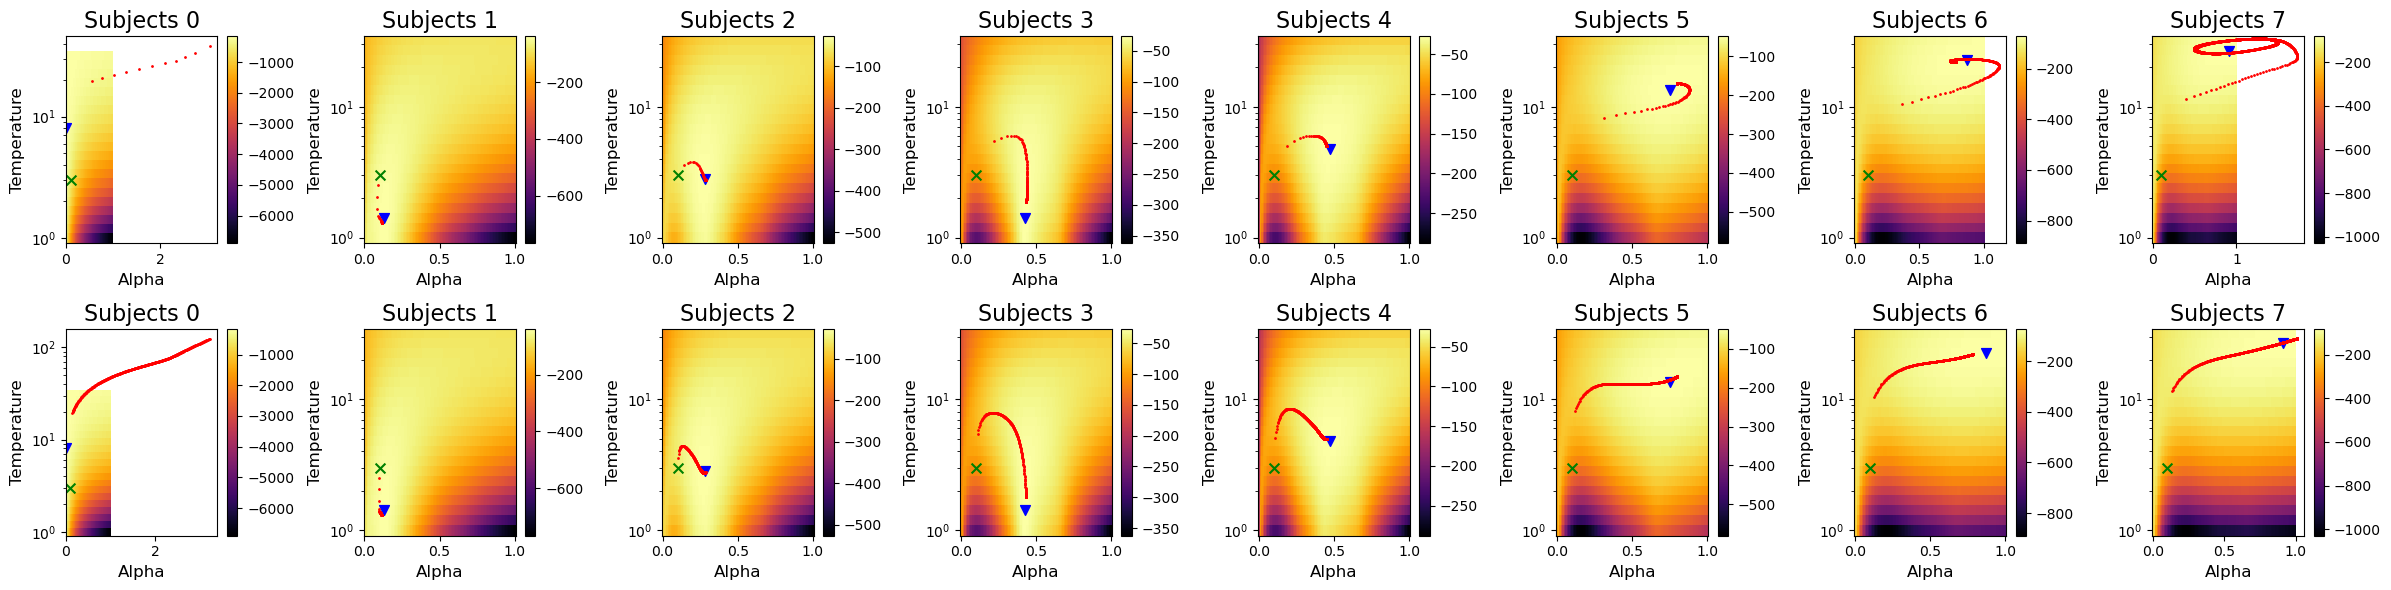

In [16]:
X, Y = np.meshgrid(taus, alphas)
fig,ax = plt.subplots(len(learn_rates), nSubject, figsize = (3*nSubject,3*len(learn_rates)))
for s in range(nSubject):
    for l, learn_rate in enumerate(learn_rates):
        im = ax[l][s].pcolormesh(Y, X, iter_errors[s,:,:], cmap = 'inferno')
        ax[l][s].scatter(best_param['Subject%d'%s][0], best_param['Subject%d'%s][1], s = 50, c = 'blue', marker = 'v')
        
        # filter = gradient_trajectories['%s,%d'%(sub,l)][np.where((gradient_trajectories['%s,%d'%(sub,l)][:,0]>0)&(gradient_trajectories['%s,%d'%(sub,l)][:,0]<1)&(gradient_trajectories['%s,%d'%(sub,l)][:,1]<1000)&(gradient_trajectories['%s,%d'%(sub,l)][:,1]>1))]
        # ax.scatter(filter[:,0], filter[:,1], s = 1, c = 'r')
        # ax.scatter(filter[-1,0], filter[-1,1], s = 50, c = 'yellow', marker = 'x')
        
        #filter = gradient_trajectories['%s,%d'%(sub,l)][np.where((gradient_trajectories['%s,%d'%(sub,l)][:,0]>0)&(gradient_trajectories['%s,%d'%(sub,l)][:,0]<1)&(gradient_trajectories['%s,%d'%(sub,l)][:,1]<1000)&(gradient_trajectories['%s,%d'%(sub,l)][:,1]>1))]
        ax[l][s].scatter(gradient_trajectories['%s,%d'%(s,l)][:,0], gradient_trajectories['%s,%d'%(s,l)][:,1], s = 1, c = 'red')
        ax[l][s].scatter(gradient_trajectories['%s,%d'%(s,l)][0,0], gradient_trajectories['%s,%d'%(s,l)][0,1], s = 50, c = 'green', marker = 'x')
        
        ax[l][s].set_xlabel('Alpha', fontsize = 12)
        ax[l][s].set_title('Subjects %d'%s, fontsize = 16)
        ax[l][s].set_ylabel('Temperature', fontsize = 12)
        # make y axis logarithmic
        ax[l][s].set_yscale('log')
        divider = make_axes_locatable(ax[l][s])
        #cax = divider.append_axes('right', size='5%', pad=0.5)
        fig.colorbar(im, ax = ax[l][s])
plt.tight_layout()